## Limpieza 10K Bayahibe

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
bayahibe_soup = BeautifulSoup(open("resultados_bayahibe_2024_10k.html"), "html.parser")

In [ ]:
def scrap_sdc_table(soup):

  header = soup.find_all("tr")[0]
  header = [cell.text for cell in header.find_all("th")]

  series = []
  for row in soup.find_all("tr"):
    row = [cell.text for cell in row.find_all("td")]
    if len(row) <= 0:
      continue
    serie = pd.Series(row, index=header)
    series.append(serie)

  header = soup.find_all("tr")[0]
  header = [cell.text for cell in header.find_all("th")]

  df = pd.DataFrame(series)

  return df

In [ ]:
bayahibe_df = scrap_sdc_table(bayahibe_soup)

In [ ]:
bayahibe_df["Name"] = bayahibe_df["Name"].map(lambda x: x.replace("\n", "")[1:])

In [ ]:
bayahibe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Place            532 non-null    object
 1   Bib              532 non-null    object
 2   Name             532 non-null    object
 3   Age              532 non-null    object
 4   Gender           532 non-null    object
 5   Ctrl  5.5K       532 non-null    object
 6   Ctrl  5.5KPace   532 non-null    object
 7   Ctrl  5.5KPlace  532 non-null    object
 8   Finish           532 non-null    object
 9   FinishPace       532 non-null    object
 10  FinishPlace      532 non-null    object
 11  ClockTime        532 non-null    object
 12  ChipTime         532 non-null    object
 13  Pace             532 non-null    object
 14  DivisionPlace    532 non-null    object
 15  Division         532 non-null    object
dtypes: object(16)
memory usage: 66.6+ KB


In [ ]:
column_names = {
    "Ctrl  5.5K": "Ctrl 5.5K",
    "Ctrl  5.5KPace": "Ctrl 5.5K Pace",
    "Ctrl  5.5KPlace": "Ctrl 5.5K Place",
    "FinishPace": "Finish Pace",
    "FinishPlace": "Finish Place",
    "ClockTime": "Clock Time",
    "ChipTime": "Chip Time",
    "DivisionPlace": "Division Place"
}
bayahibe_df = bayahibe_df.rename(columns=column_names)

In [ ]:
bayahibe_df["DQ"] = bayahibe_df["Place"].map(lambda x: True if x == "DQ" else False)
bayahibe_df["DNF"] = bayahibe_df["Clock Time"].map(lambda x: True if x == "DNF" else False)

In [ ]:
bayahibe_df = bayahibe_df.replace("", np.nan)
bayahibe_df = bayahibe_df.replace("DQ", np.nan)
bayahibe_df = bayahibe_df.replace("DNF", np.nan)

In [ ]:
int_columns = [
    "Division Place",
    "Finish Place",
    "Ctrl 5.5K Place",
    "Age",
    "Bib",
    "Place"
]
bayahibe_df[int_columns] = bayahibe_df[int_columns].astype(float)

In [ ]:
def convert_time_string_to_seconds(time_string):

  if pd.isna(time_string):
    return np.nan

  time_data = time_string.split(":")

  hours, minutes, seconds = 0, 0, 0
  if(len(time_data) == 2):
    minutes, seconds = time_data
  else:
    hours, minutes, seconds = time_data

  return int(hours) * 60 * 60 + int(minutes) * 60 + int(seconds)

In [ ]:
def convert_seconds_to_time_string(seconds):
  return str(datetime.timedelta(seconds=seconds))

In [ ]:
bayahibe_df["Clock Time"] = bayahibe_df["Clock Time"].map(lambda x: x.replace("Video", "") if not pd.isna(x) else x)

In [ ]:
time_columns = [
    "Ctrl 5.5K",
    "Ctrl 5.5K Pace",
    "Finish",
    "Finish Pace",
    "Chip Time",
    "Pace",
    "Clock Time"
]
bayahibe_df[time_columns] = bayahibe_df[time_columns].map(lambda x: convert_time_string_to_seconds(x))

In [ ]:
bayahibe_df

,Place,Bib,Name,Age,Gender,Ctrl 5.5K,Ctrl 5.5K Pace,Ctrl 5.5K Place,Finish,Finish Pace,Finish Place,Clock Time,Chip Time,Pace,Division Place,Division,DQ,DNF
0,1.0,1.0,JilbertoSantana Manzano,26.0,M,986.0,180.0,1.0,850.0,189.0,1.0,1837.0,1837.0,184.0,1.0,M OP,False,False
1,2.0,55.0,Jose RamonGratero,24.0,M,1003.0,182.0,2.0,871.0,193.0,2.0,1874.0,1874.0,188.0,2.0,M OP,False,False
2,3.0,350.0,AlexanderDe La Rosa De Los Sa,21.0,M,1024.0,186.0,3.0,889.0,198.0,3.0,1913.0,1913.0,191.0,3.0,M OP,False,False
3,4.0,349.0,Wide MayerMercier,18.0,M,1036.0,188.0,4.0,897.0,199.0,4.0,1933.0,1933.0,193.0,1.0,M 18-29,False,False
4,5.0,523.0,Andrews AndersoMontilla Ayala,23.0,M,1037.0,188.0,5.0,913.0,203.0,6.0,1952.0,1951.0,195.0,2.0,M 18-29,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,528.0,455.0,AngelaSoto Baez,23.0,F,3880.0,705.0,519.0,3738.0,831.0,517.0,7677.0,7619.0,762.0,30.0,F 18-29,False,False
528,532.0,159.0,Melissa MilagroAlonso,19.0,F,2355.0,428.0,345.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
529,NaN,107.0,ChristalRamirez,27.0,F,2033.0,370.0,228.0,1964.0,436.0,NaN,NaN,3998.0,400.0,NaN,NaN,True,False
530,NaN,493.0,Rocio MirulquiRijo Rijo,51.0,F,1870.0,340.0,156.0,1650.0,367.0,NaN,NaN,3521.0,352.0,NaN,NaN,True,False


In [ ]:
convert_seconds_to_time_string(bayahibe_df["Finish"].mean())

'0:33:22.116761'

## Limpieza Maratón Santo Domingo

In [ ]:
maraton_soup = BeautifulSoup(open("tabla_maraton_de_santo_domingo_sdc.html"), "html.parser")

In [ ]:
df_maraton = scrap_sdc_table(maraton_soup)

In [ ]:
df_maraton

,Place,Bib,Name,Age,Gender,Country,5K,5KPace,5KPlace,10K,...,36KPace,36KPlace,41K,41KPace,41KPlace,ClockTime,ChipTime,Pace,DivisionPlace,Division
0,1,29,\n\nA\n\n\nAlexis\nBautista\n\n,35,M,US,16:53,3:23,1,33:56,...,3:33,1,2:26:32,3:34,1,2:30:47 Video,2:30:45,3:34,1,M OP
1,2,67,\n\nF\n\n\nFranklin\nJimenez\n\n,27,M,US,17:04,3:25,3,34:41,...,3:41,2,2:32:32,3:43,2,2:37:01 Video,2:36:58,3:43,2,M OP
2,3,5,\n\nB\n\n\nBraylin\nSantana Tejada\n\n,32,M,US,17:06,3:25,4,34:26,...,3:44,3,2:35:17,3:47,3,2:39:37 Video,2:39:37,3:47,3,M OP
3,4,14,\n\nJ\n\n\nJose\nHernandez\n\n,52,M,US,20:03,4:00,7,40:42,...,4:13,5,2:53:53,4:15,4,3:00:13 Video,2:58:56,4:15,1,M 50-59
4,5,115,\n\nY\n\n\nYusheng\nNi\n\n,54,M,US,19:29,3:54,6,40:07,...,4:21,6,2:59:54,4:23,5,3:04:57 Video,3:04:55,4:23,2,M 50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,DQ,76,\n\nR\n\n\nRaisa Margarita\nSoliman Felix\n\n,60,F,US,50:30,10:06,136,1:44:12,...,,,,,,DQ,4:01:09,5:43,,
133,DQ,107,\n\nM\n\n\nMiguel\nMartinez\n\n,41,M,US,33:57,6:48,108,1:06:29,...,8:02,95,,,,DQ,2:23:20,3:24,,
134,DQ,121,\n\nE\n\n\nErnesto\nDe Leon\n\n,38,M,US,27:20,5:28,53,,...,,,,,,DQ,2:02:30,2:55,,
135,DQ,122,\n\nJ\n\n\nJuan Manuel\nAdames Silva\n\n,48,M,US,35:22,7:04,118,,...,,,,,,DQ,2:52:31,4:05,,


In [ ]:
column_names = {
    "Ctrl  5.5K": "Ctrl 5.5K",
    "Ctrl  5.5KPace": "Ctrl 5.5K Pace",
    "Ctrl  5.5KPlace": "Ctrl 5.5K Place",
    "FinishPace": "Finish Pace",
    "FinishPlace": "Finish Place",
    "ClockTime": "Clock Time",
    "ChipTime": "Chip Time",
    "DivisionPlace": "Division Place"
}

df_maraton = df_maraton.rename(columns=column_names)

df_maraton["Name"] = df_maraton["Name"].map(lambda x: x.replace("\n", "")[1:])

df_maraton["DQ"] = df_maraton["Place"].map(lambda x: True if x == "DQ" else False)
df_maraton["DNF"] = df_maraton["Clock Time"].map(lambda x: True if x == "DNF" else False)

df_maraton = df_maraton.replace("", np.nan)
df_maraton = df_maraton.replace("DQ", np.nan)
df_maraton = df_maraton.replace("DNF", np.nan)

int_columns = [
    "Division Place",
    "Age",
    "Bib",
    "Place"
]
df_maraton[int_columns] = df_maraton[int_columns].astype(float)

df_maraton["Clock Time"] = df_maraton["Clock Time"].map(lambda x: x.replace("Video", "") if not pd.isna(x) else x)

time_columns = [
    "Chip Time",
    "Pace",
    "Clock Time"
]
df_maraton[time_columns] = df_maraton[time_columns].map(lambda x: convert_time_string_to_seconds(x))

In [ ]:
df_maraton = df_maraton.rename(columns = {"DNQ": "DQ"})

In [ ]:
df_maraton

,Place,Bib,Name,Age,Gender,Country,5K,5KPace,5KPlace,10K,...,41K,41KPace,41KPlace,Clock Time,Chip Time,Pace,Division Place,Division,DQ,DNF
0,1.0,29.0,AlexisBautista,35.0,M,US,16:53,3:23,1,33:56,...,2:26:32,3:34,1,9047.0,9045.0,214.0,1.0,M OP,False,False
1,2.0,67.0,FranklinJimenez,27.0,M,US,17:04,3:25,3,34:41,...,2:32:32,3:43,2,9421.0,9418.0,223.0,2.0,M OP,False,False
2,3.0,5.0,BraylinSantana Tejada,32.0,M,US,17:06,3:25,4,34:26,...,2:35:17,3:47,3,9577.0,9577.0,227.0,3.0,M OP,False,False
3,4.0,14.0,JoseHernandez,52.0,M,US,20:03,4:00,7,40:42,...,2:53:53,4:15,4,10813.0,10736.0,255.0,1.0,M 50-59,False,False
4,5.0,115.0,YushengNi,54.0,M,US,19:29,3:54,6,40:07,...,2:59:54,4:23,5,11097.0,11095.0,263.0,2.0,M 50-59,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,NaN,76.0,Raisa MargaritaSoliman Felix,60.0,F,US,50:30,10:06,136,1:44:12,...,NaN,NaN,NaN,NaN,14469.0,343.0,NaN,NaN,True,False
133,NaN,107.0,MiguelMartinez,41.0,M,US,33:57,6:48,108,1:06:29,...,NaN,NaN,NaN,NaN,8600.0,204.0,NaN,NaN,True,False
134,NaN,121.0,ErnestoDe Leon,38.0,M,US,27:20,5:28,53,NaN,...,NaN,NaN,NaN,NaN,7350.0,175.0,NaN,NaN,True,False
135,NaN,122.0,Juan ManuelAdames Silva,48.0,M,US,35:22,7:04,118,NaN,...,NaN,NaN,NaN,NaN,10351.0,245.0,NaN,NaN,True,False


## Consolidación de históricos

In [ ]:
columnas_a_consolidar = [
    "Event Name",
    "Event Distance (km)",
    "Event Year",
    "Name",
    "Age",
    "Bib",
    "Gender",
    #"Country",
    "Place",
    "Clock Time",
    "Chip Time",
    "Pace",
    "Division",
    "Division Place",
    "DQ",
    "DNF"
]

bayahibe_df["Event Name"] = "Bayahibe 10k"
bayahibe_df["Event Year"] = 2024
bayahibe_df["Event Distance (km)"] = 10

df_maraton["Event Name"] = "Maratón de Santo Domingo"
df_maraton["Event Year"] = 2024
df_maraton["Event Distance (km)"] = 42

df_consolidado = pd.concat([
    bayahibe_df[columnas_a_consolidar],
    df_maraton[columnas_a_consolidar]
]).reset_index(drop=True)

df_consolidado

,Event Name,Event Distance (km),Event Year,Name,Age,Bib,Gender,Place,Clock Time,Chip Time,Pace,Division,Division Place,DQ,DNF
0,Bayahibe 10k,10,2024,JilbertoSantana Manzano,26.0,1.0,M,1.0,1837.0,1837.0,184.0,M OP,1.0,False,False
1,Bayahibe 10k,10,2024,Jose RamonGratero,24.0,55.0,M,2.0,1874.0,1874.0,188.0,M OP,2.0,False,False
2,Bayahibe 10k,10,2024,AlexanderDe La Rosa De Los Sa,21.0,350.0,M,3.0,1913.0,1913.0,191.0,M OP,3.0,False,False
3,Bayahibe 10k,10,2024,Wide MayerMercier,18.0,349.0,M,4.0,1933.0,1933.0,193.0,M 18-29,1.0,False,False
4,Bayahibe 10k,10,2024,Andrews AndersoMontilla Ayala,23.0,523.0,M,5.0,1952.0,1951.0,195.0,M 18-29,2.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,Maratón de Santo Domingo,42,2024,Raisa MargaritaSoliman Felix,60.0,76.0,F,NaN,NaN,14469.0,343.0,NaN,NaN,True,False
665,Maratón de Santo Domingo,42,2024,MiguelMartinez,41.0,107.0,M,NaN,NaN,8600.0,204.0,NaN,NaN,True,False
666,Maratón de Santo Domingo,42,2024,ErnestoDe Leon,38.0,121.0,M,NaN,NaN,7350.0,175.0,NaN,NaN,True,False
667,Maratón de Santo Domingo,42,2024,Juan ManuelAdames Silva,48.0,122.0,M,NaN,NaN,10351.0,245.0,NaN,NaN,True,False


## EDA

In [ ]:
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 669 entries, 0 to 136
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Event Name           669 non-null    object 
 1   Event Distance (km)  669 non-null    int64  
 2   Event Year           669 non-null    int64  
 3   Name                 669 non-null    object 
 4   Age                  663 non-null    float64
 5   Bib                  669 non-null    float64
 6   Gender               669 non-null    object 
 7   Place                656 non-null    float64
 8   Clock Time           645 non-null    float64
 9   Chip Time            658 non-null    float64
 10  Pace                 658 non-null    float64
 11  Division             645 non-null    object 
 12  Division Place       645 non-null    float64
 13  DQ                   669 non-null    bool   
 14  DNF                  669 non-null    bool   
dtypes: bool(2), float64(7), int64(2), object(4)
m

In [ ]:
df_consolidado.describe()

,Event Distance (km),Event Year,Age,Bib,Place,Clock Time,Chip Time,Pace,Division Place
count,669.000000,669.0,663.000000,669.000000,656.000000,645.000000,658.000000,658.000000,645.000000
mean,16.553064,2024.0,38.493213,249.001495,226.243902,6433.570543,6450.092705,405.340426,30.522481
std,12.923043,0.0,11.742949,175.660230,159.324207,5175.423895,5160.431204,95.523964,26.358756
min,10.000000,2024.0,1.000000,1.000000,1.000000,1837.000000,1837.000000,175.000000,1.000000
25%,10.000000,2024.0,30.000000,93.000000,82.750000,3580.000000,3556.500000,332.250000,9.000000
50%,10.000000,2024.0,38.000000,219.000000,201.500000,4405.000000,4375.500000,398.500000,23.000000
75%,10.000000,2024.0,46.000000,402.000000,365.250000,5537.000000,5651.000000,465.000000,46.000000
max,42.000000,2024.0,72.000000,600.000000,532.000000,23994.000000,23987.000000,762.000000,106.000000


In [ ]:
df_consolidado.select_dtypes(include="object")

,Event Name,Name,Gender,Division
0,Bayahibe 10k,JilbertoSantana Manzano,M,M OP
1,Bayahibe 10k,Jose RamonGratero,M,M OP
2,Bayahibe 10k,AlexanderDe La Rosa De Los Sa,M,M OP
3,Bayahibe 10k,Wide MayerMercier,M,M 18-29
4,Bayahibe 10k,Andrews AndersoMontilla Ayala,M,M 18-29
...,...,...,...,...
132,Maratón de Santo Domingo,Raisa MargaritaSoliman Felix,F,NaN
133,Maratón de Santo Domingo,MiguelMartinez,M,NaN
134,Maratón de Santo Domingo,ErnestoDe Leon,M,NaN
135,Maratón de Santo Domingo,Juan ManuelAdames Silva,M,NaN


In [ ]:
df_consolidado["Event Name"].value_counts(normalize=True)

,proportion
Event Name,
Bayahibe 10k,0.795217
Maratón de Santo Domingo,0.204783


<Axes: ylabel='proportion'>

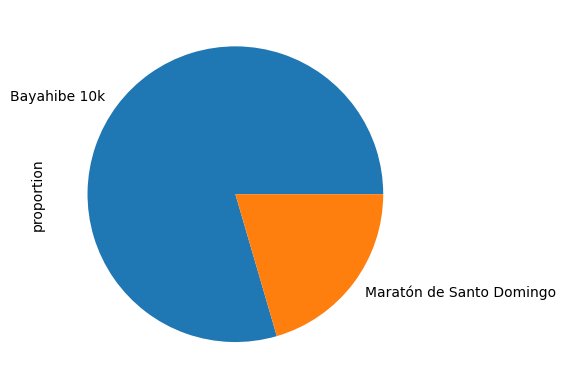

In [ ]:
df_consolidado["Event Name"].value_counts(normalize=True).plot(kind="pie")

<Axes: xlabel='Gender'>

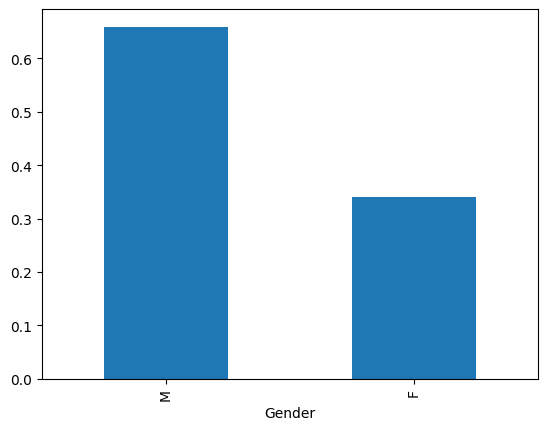

In [ ]:
df_consolidado["Gender"].value_counts(normalize=True).plot(kind="bar")

<Axes: >

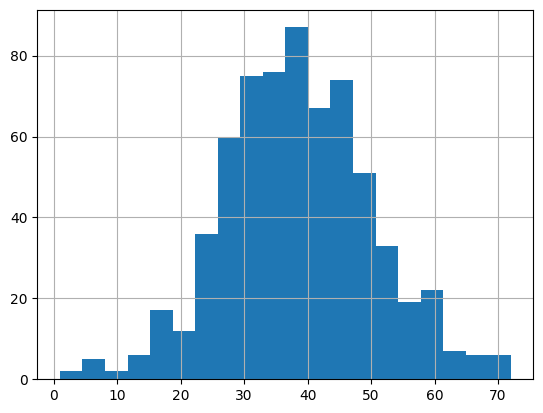

In [ ]:
df_consolidado["Age"].hist(bins=20)

<Axes: xlabel='DQ'>

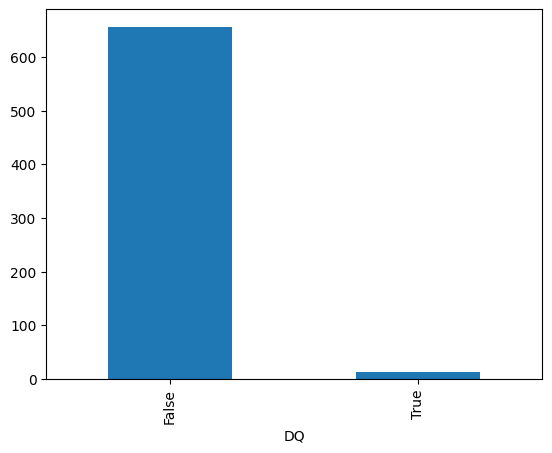

In [ ]:
df_consolidado["DQ"].value_counts().plot(kind="bar")

In [ ]:
df_consolidado

,Event Name,Event Distance (km),Event Year,Name,Age,Bib,Gender,Place,Clock Time,Chip Time,Pace,Division,Division Place,DQ,DNF
0,Bayahibe 10k,10,2024,JilbertoSantana Manzano,26.0,1.0,M,1.0,1837.0,1837.0,184.0,M OP,1.0,False,False
1,Bayahibe 10k,10,2024,Jose RamonGratero,24.0,55.0,M,2.0,1874.0,1874.0,188.0,M OP,2.0,False,False
2,Bayahibe 10k,10,2024,AlexanderDe La Rosa De Los Sa,21.0,350.0,M,3.0,1913.0,1913.0,191.0,M OP,3.0,False,False
3,Bayahibe 10k,10,2024,Wide MayerMercier,18.0,349.0,M,4.0,1933.0,1933.0,193.0,M 18-29,1.0,False,False
4,Bayahibe 10k,10,2024,Andrews AndersoMontilla Ayala,23.0,523.0,M,5.0,1952.0,1951.0,195.0,M 18-29,2.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Maratón de Santo Domingo,42,2024,Raisa MargaritaSoliman Felix,60.0,76.0,F,NaN,NaN,14469.0,343.0,NaN,NaN,True,False
133,Maratón de Santo Domingo,42,2024,MiguelMartinez,41.0,107.0,M,NaN,NaN,8600.0,204.0,NaN,NaN,True,False
134,Maratón de Santo Domingo,42,2024,ErnestoDe Leon,38.0,121.0,M,NaN,NaN,7350.0,175.0,NaN,NaN,True,False
135,Maratón de Santo Domingo,42,2024,Juan ManuelAdames Silva,48.0,122.0,M,NaN,NaN,10351.0,245.0,NaN,NaN,True,False


<Axes: xlabel='Age', ylabel='Clock Time'>

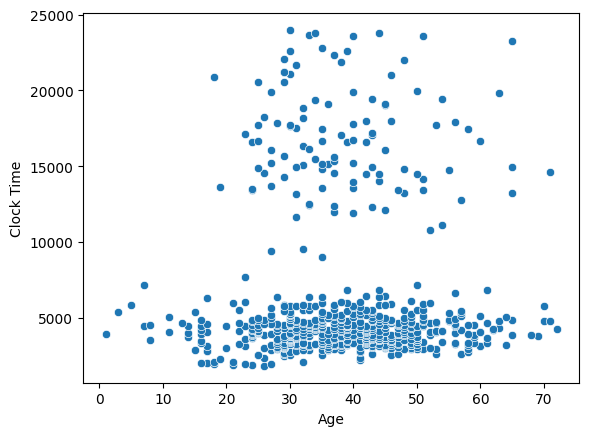

In [ ]:
sns.scatterplot(data=df_consolidado, x="Age", y="Clock Time")

<Axes: xlabel='Age', ylabel='Clock Time'>

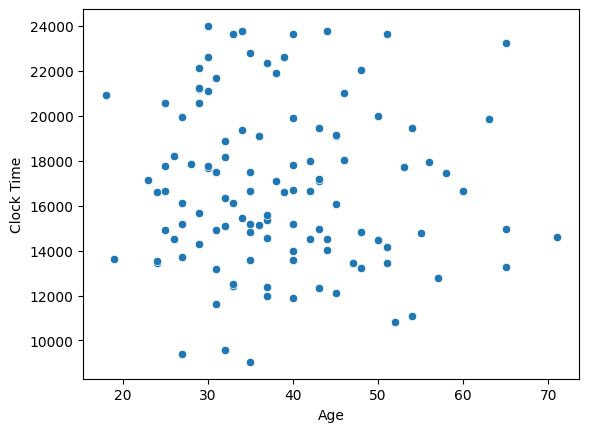

In [ ]:
sns.scatterplot(data=df_consolidado[df_consolidado["Event Name"] == "Maratón de Santo Domingo"], x="Age", y="Clock Time")

<Axes: xlabel='Age', ylabel='Clock Time'>

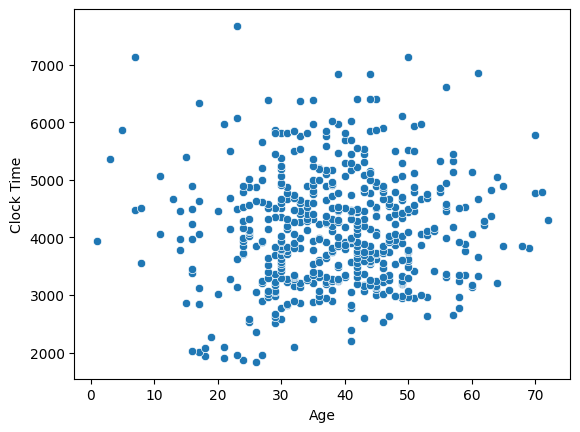

In [ ]:
sns.scatterplot(data=df_consolidado[df_consolidado["Event Name"] == "Bayahibe 10k"], x="Age", y="Clock Time")

In [ ]:
df_consolidado.select_dtypes(include="number").corr()

,Event Distance (km),Event Year,Age,Bib,Place,Clock Time,Chip Time,Pace,Division Place
Event Distance (km),1.000000,NaN,0.006582,-0.501127,-0.496912,0.941551,0.932082,-0.098568,-0.396272
Event Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,0.006582,NaN,1.000000,0.011674,0.032389,0.004650,0.009009,0.037816,0.120511
Bib,-0.501127,NaN,0.011674,1.000000,0.152675,-0.459632,-0.466001,-0.040564,0.123213
Place,-0.496912,NaN,0.032389,0.152675,1.000000,-0.298323,-0.300266,0.834032,0.649695
Clock Time,0.941551,NaN,0.004650,-0.459632,-0.298323,1.000000,0.999776,0.217327,-0.266862
Chip Time,0.932082,NaN,0.009009,-0.466001,-0.300266,0.999776,1.000000,0.192238,-0.268390
Pace,-0.098568,NaN,0.037816,-0.040564,0.834032,0.217327,0.192238,1.000000,0.506719
Division Place,-0.396272,NaN,0.120511,0.123213,0.649695,-0.266862,-0.268390,0.506719,1.000000


<Axes: xlabel='Event Name', ylabel='Clock Time'>

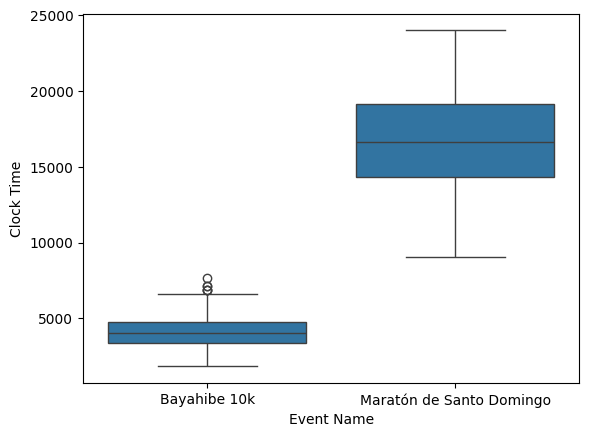

In [ ]:
sns.boxplot(data=df_consolidado, x="Event Name", y="Clock Time")

<Axes: xlabel='Gender', ylabel='Clock Time'>

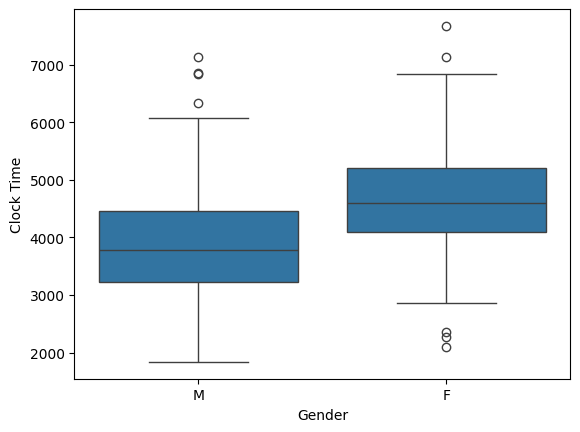

In [ ]:
sns.boxplot(data=df_consolidado[df_consolidado["Event Name"] == "Bayahibe 10k"], x="Gender", y="Clock Time")

<Axes: xlabel='Gender', ylabel='Clock Time'>

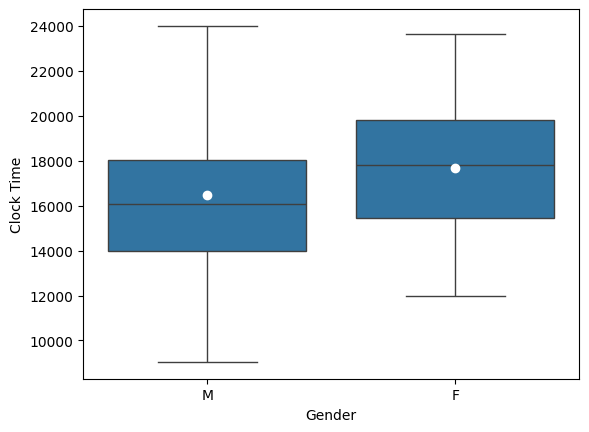

In [ ]:
sns.boxplot(data=df_consolidado[df_consolidado["Event Name"] == "Maratón de Santo Domingo"], x="Gender", y="Clock Time", showmeans=True, meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"white"})

<Axes: xlabel='Event Name', ylabel='Pace'>

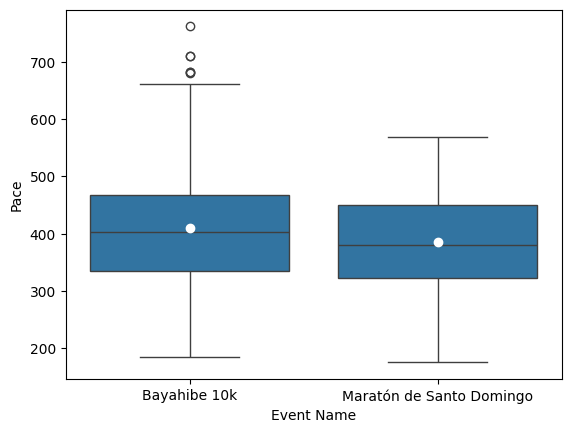

In [ ]:
sns.boxplot(data=df_consolidado, x="Event Name", y="Pace", showmeans=True, meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"white"})

<Axes: xlabel='Gender', ylabel='Pace'>

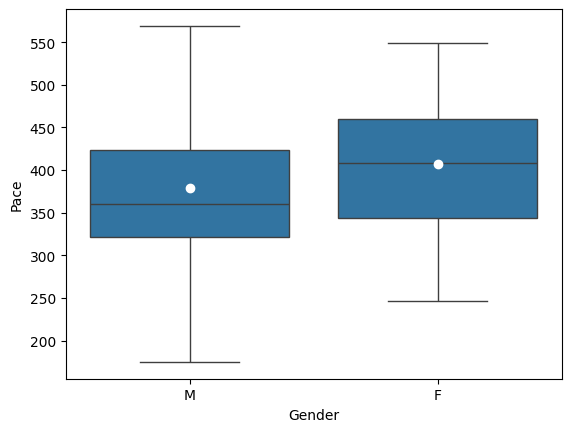

In [ ]:
sns.boxplot(data=df_consolidado[df_consolidado["Event Name"] == "Maratón de Santo Domingo"], x="Gender", y="Pace", showmeans=True, meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"white"})